# 02 — Exploratory Data Analysis

**NIFTY 50 Next-Day Direction Prediction**

This notebook covers:
1. Feature correlation heatmap (verify no |corr| > 0.85)
2. Feature distributions by target class
3. Target class balance analysis
4. Feature-target correlations
5. Time-series plots of key features (ret_1d, vol_20d, vix_level, open_gap)

Final 12 features include `open_gap` (overnight gap) and `high_low_range` (intraday range) in place of `rsi_14` and `bn_ret_1d` which were dropped for multicollinearity. Day-of-week (`dow`) was considered but omitted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent) if 'notebooks' in str(Path.cwd()) else str(Path.cwd()))

from src.features import build_features, FEATURE_COLS

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_palette('RdBu_r')

X, y = build_features()
print(f'X shape: {X.shape}')
print(f'y distribution: up={int(y.sum())}, down={int(len(y)-y.sum())}')

X shape: (729, 12)
y distribution: up=396, down=333


## 1. Feature Correlation Heatmap

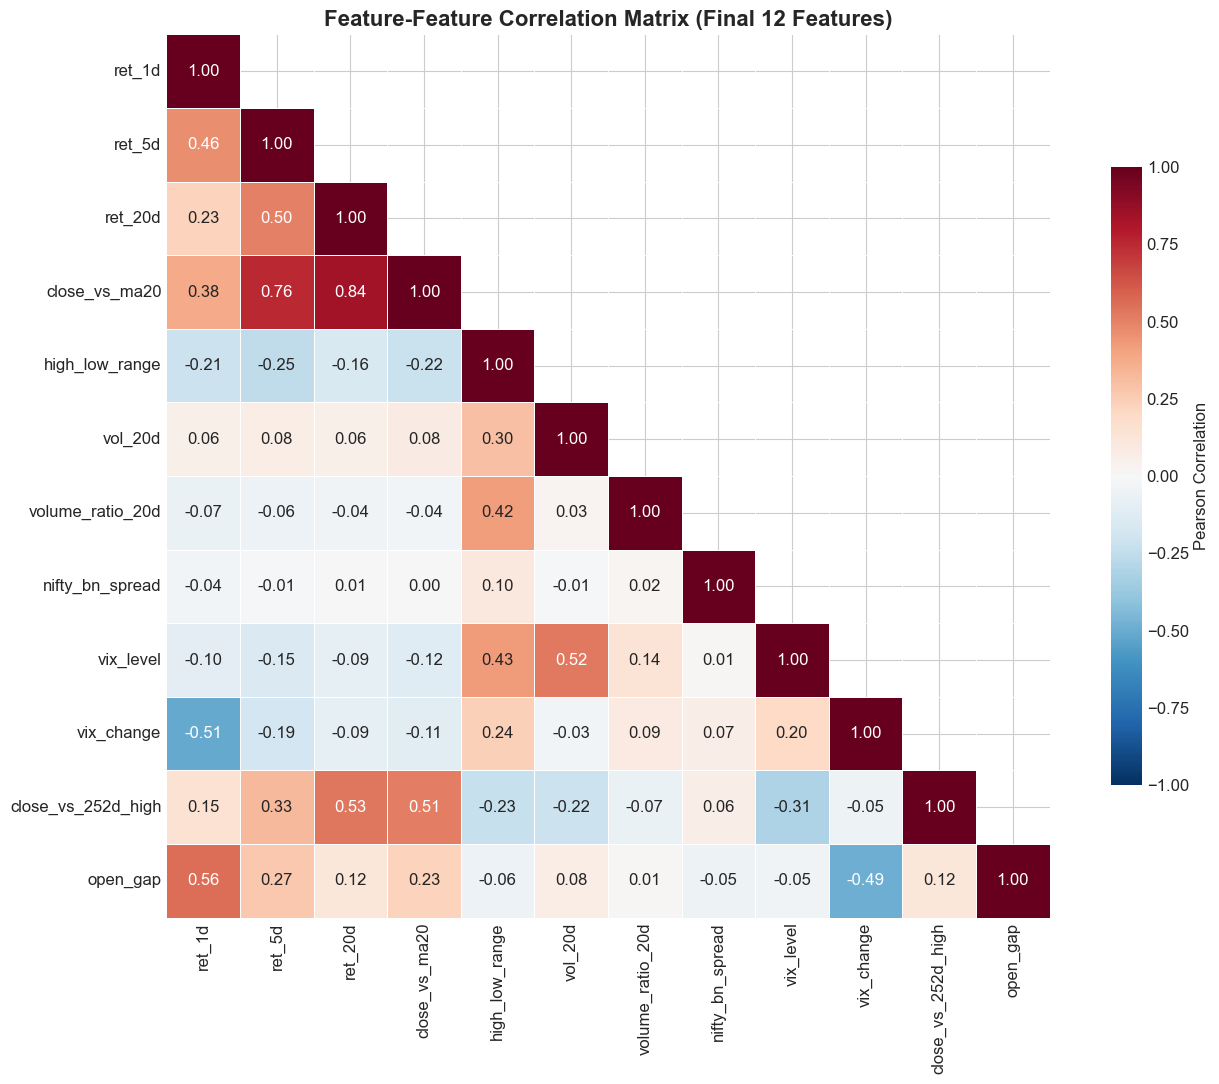


Max pairwise |correlation|: 0.8379 (ret_20d vs close_vs_ma20)
Constraint satisfied: True


In [2]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson Correlation'},
    ax=ax
)
ax.set_title('Feature-Feature Correlation Matrix (Final 12 Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Verify constraint
abs_corr = corr.abs()
np.fill_diagonal(abs_corr.values, 0)
max_corr = abs_corr.max().max()
pair = abs_corr.stack().idxmax()
print(f'\nMax pairwise |correlation|: {max_corr:.4f} ({pair[0]} vs {pair[1]})')
print(f'Constraint satisfied: {max_corr < 0.85}')

## 2. Feature Distributions (Histograms by Target Class)

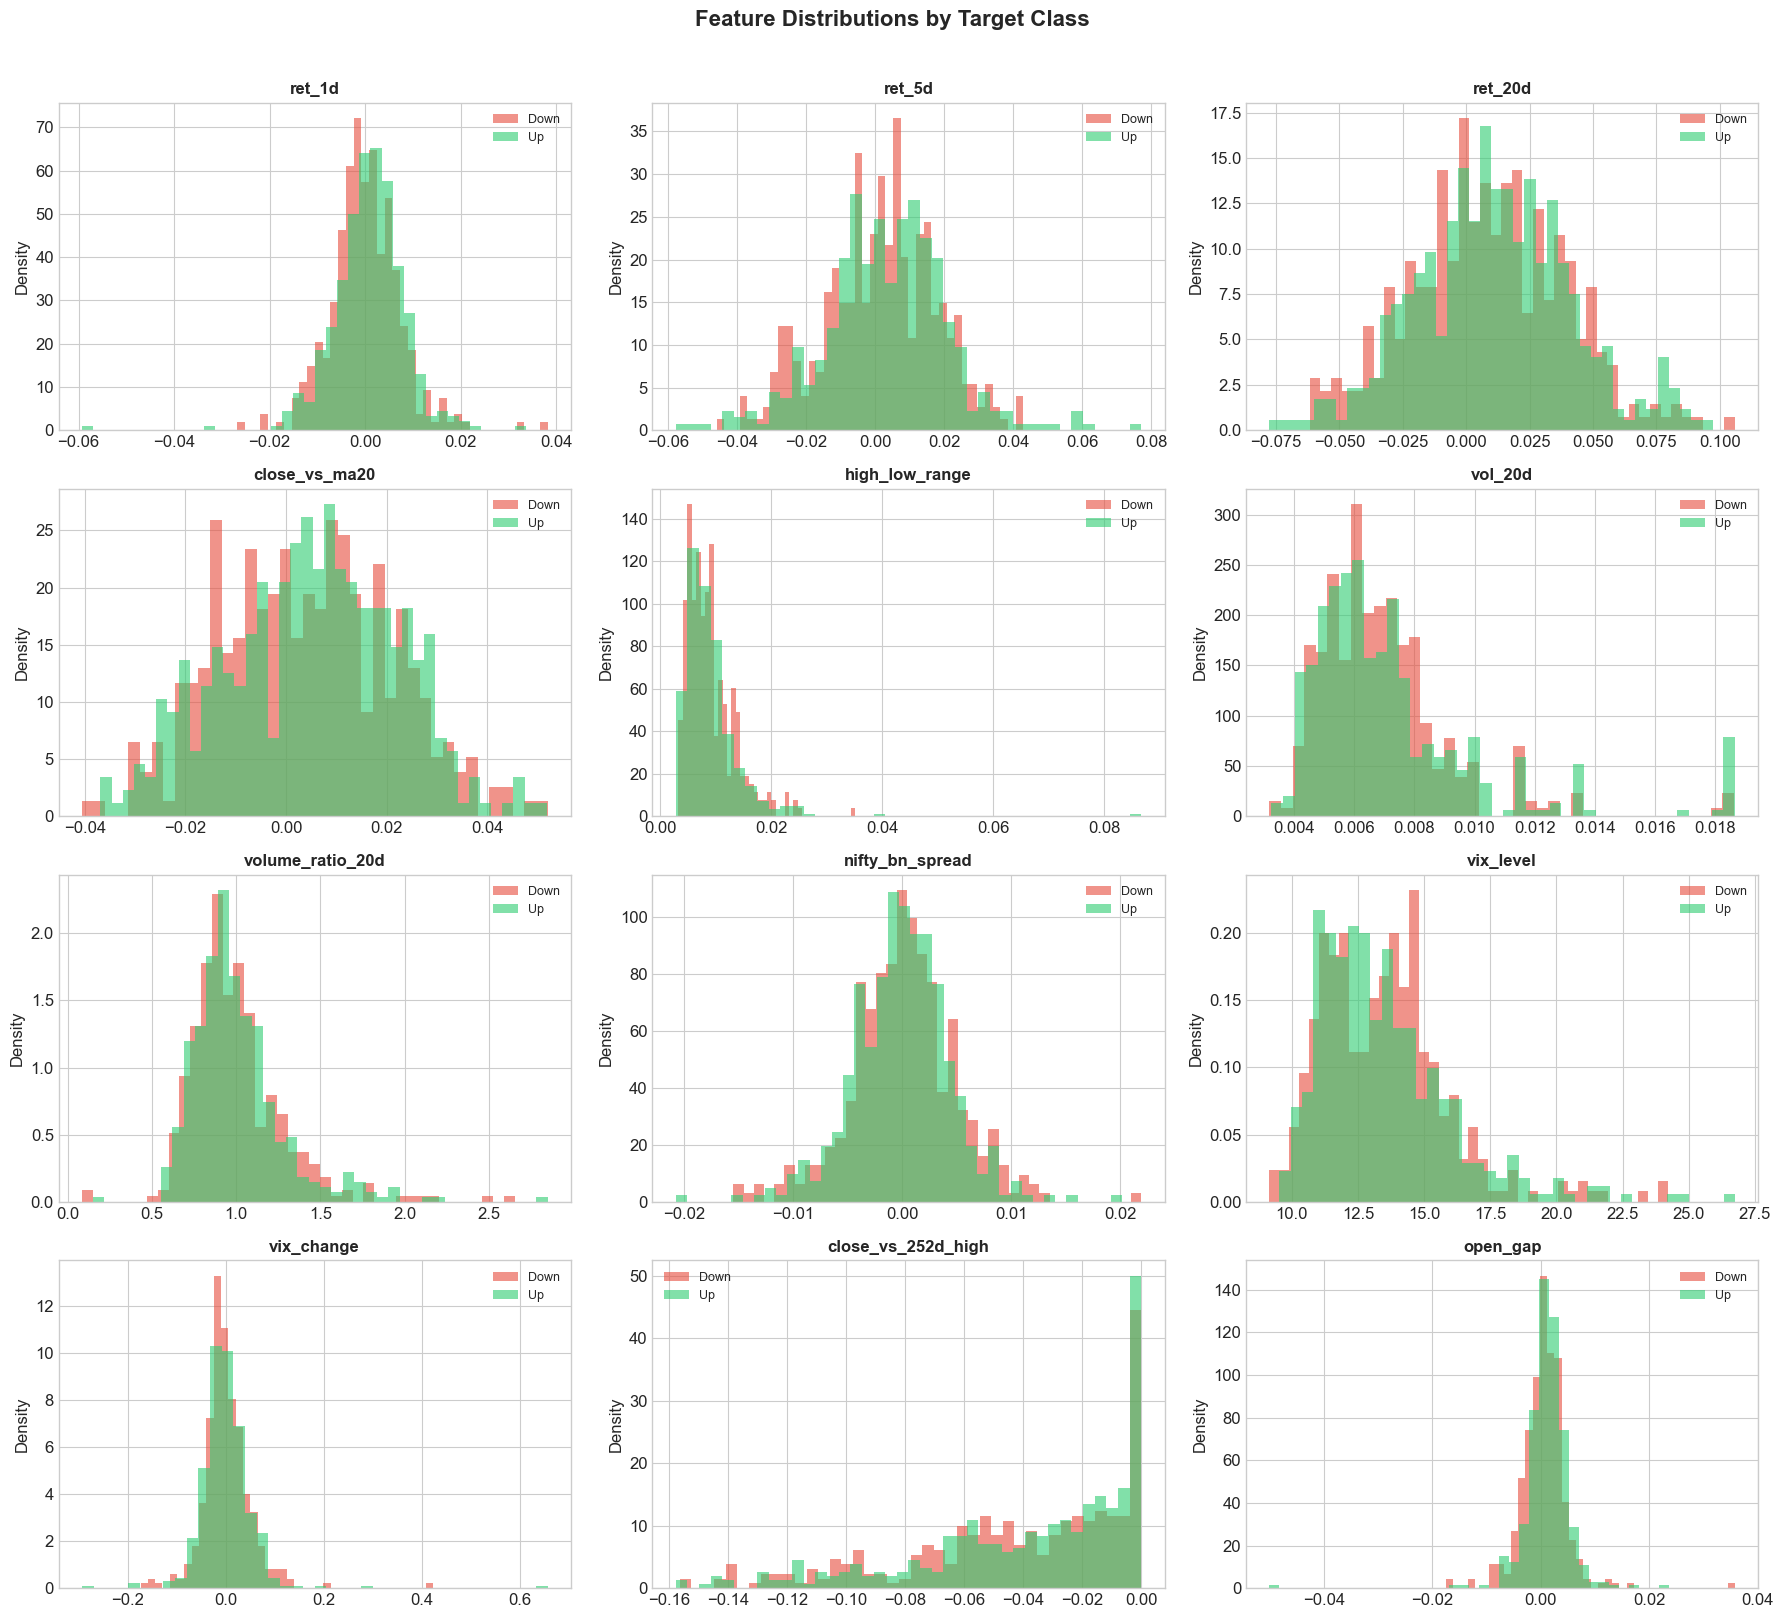

In [3]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for label, color, name in [(0, '#e74c3c', 'Down'), (1, '#2ecc71', 'Up')]:
        ax.hist(X.loc[y == label, col], bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

fig.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Target Class Balance

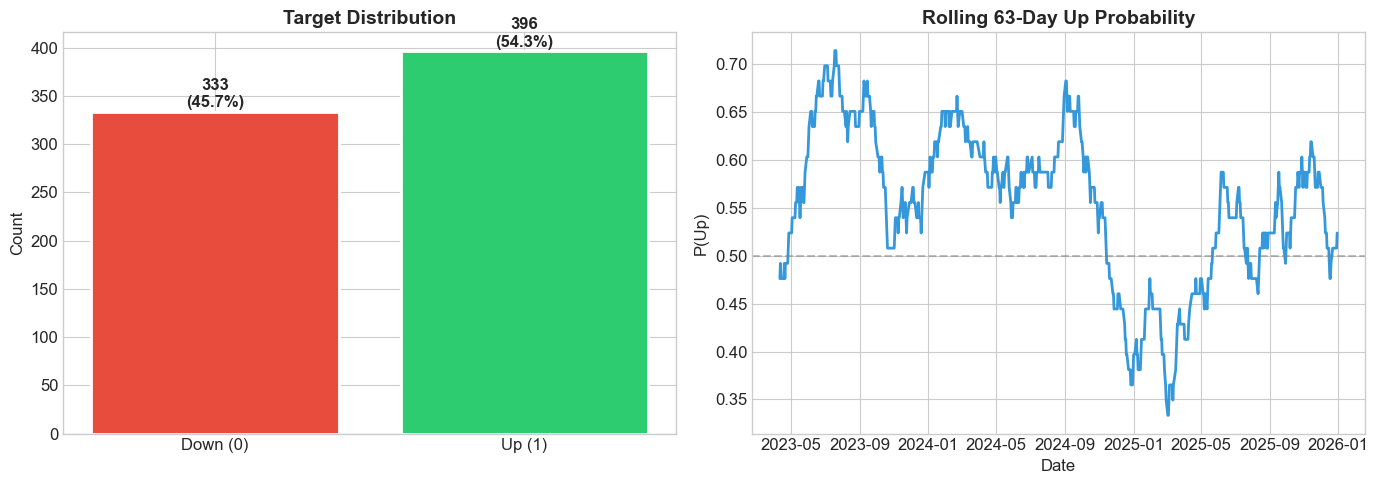

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = y.value_counts().sort_index()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Down (0)', 'Up (1)'], counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')

# Rolling target rate
rolling_rate = y.rolling(63).mean()
axes[1].plot(X.index, rolling_rate, color='#3498db', linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Rolling 63-Day Up Probability', fontsize=14, fontweight='bold')
axes[1].set_ylabel('P(Up)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../report/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature-Target Correlations

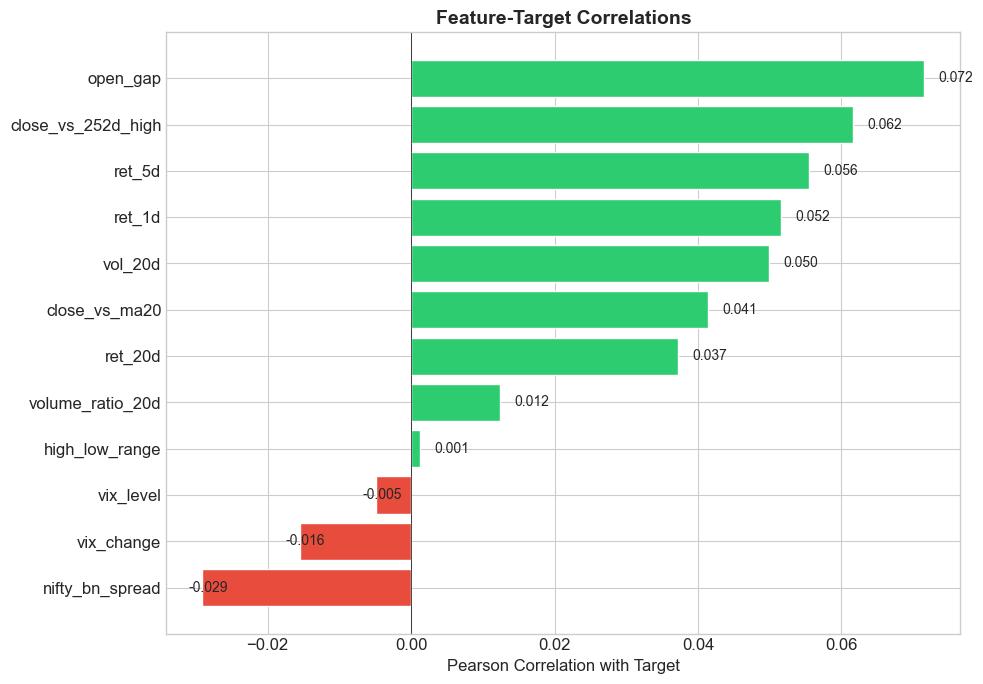

In [5]:
target_corr = X.corrwith(y).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson Correlation with Target')
ax.set_title('Feature-Target Correlations', fontsize=14, fontweight='bold')
for i, (idx, v) in enumerate(target_corr.items()):
    ax.text(v + 0.002 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../report/feature_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Time-Series Plots of Key Features

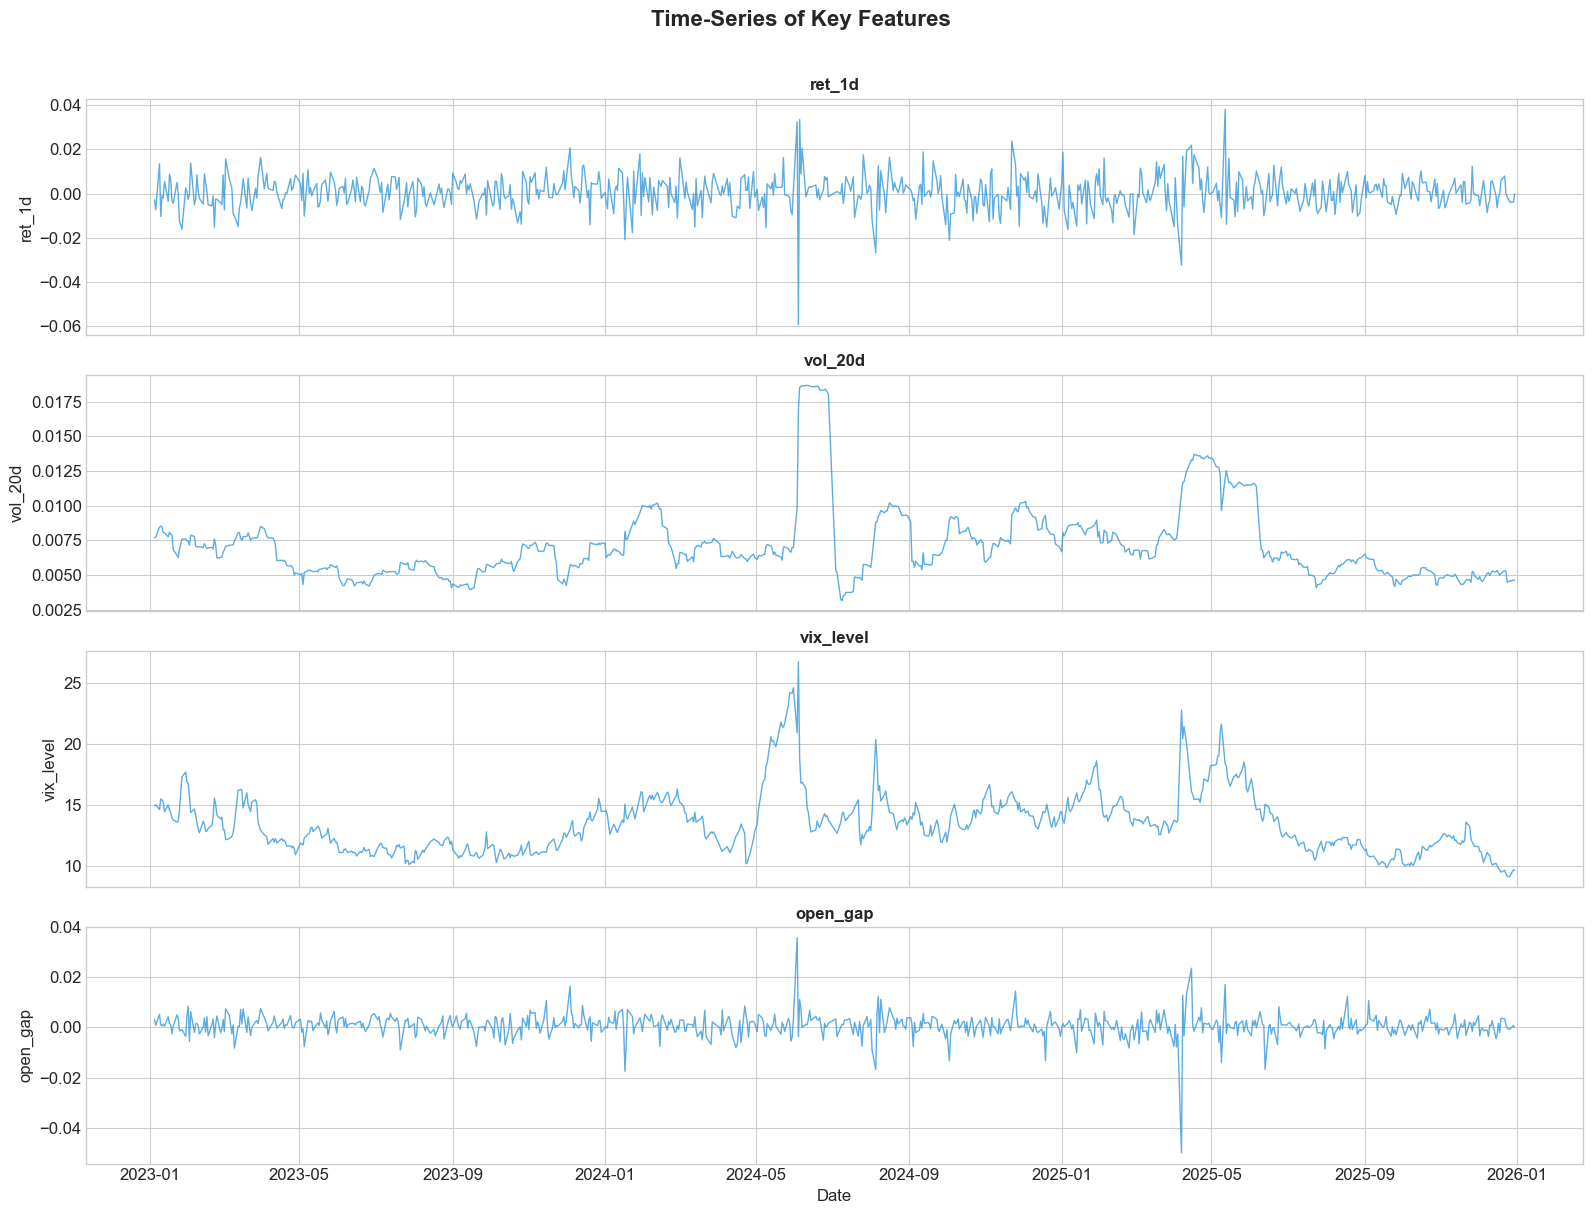

In [6]:
key_features = ['ret_1d', 'vol_20d', 'vix_level', 'open_gap']

fig, axes = plt.subplots(len(key_features), 1, figsize=(16, 12), sharex=True)
for i, feat in enumerate(key_features):
    axes[i].plot(X.index, X[feat], color='#3498db', linewidth=1, alpha=0.8)
    axes[i].set_ylabel(feat)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')

axes[-1].set_xlabel('Date')
fig.suptitle('Time-Series of Key Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/feature_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary Statistics

In [7]:
stats = X.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats['skew'] = X.skew()
stats['kurtosis'] = X.kurtosis()
print(stats.to_string())

                         mean       std       min        25%        50%        75%        max      skew   kurtosis
ret_1d               0.000492  0.007596 -0.059294  -0.003615   0.000483   0.004868   0.038183 -0.441411   7.026608
ret_5d               0.002478  0.017183 -0.057729  -0.007953   0.002691   0.013848   0.077074 -0.002575   0.968817
ret_20d              0.009866  0.030396 -0.077634  -0.010115   0.008981   0.029631   0.106002  0.094666   0.022768
close_vs_ma20        0.004587  0.017082 -0.040598  -0.007804   0.005138   0.017367   0.052041 -0.014450  -0.425054
high_low_range       0.009062  0.005284  0.002732   0.005856   0.008098   0.010765   0.086730  5.405424  65.839317
vol_20d              0.007114  0.002675  0.003169   0.005373   0.006458   0.007879   0.018674  2.177250   6.181802
volume_ratio_20d     1.005615  0.287352  0.083363   0.828117   0.950404   1.112454   2.849092  1.751959   6.318203
nifty_bn_spread      0.000048  0.004702 -0.020754  -0.002724   0.000120   0.0027

## 7. Key Findings

1. **No correlation exceeds 0.85** — max is ret_20d vs close_vs_ma20 at 0.8379, safely under the 0.85 constraint
2. **Target is near-balanced** — 54.3% up (396), 45.7% down (333)
3. **Feature changes from plan**: dropped `rsi_14` (|corr| 0.84 with close_vs_ma20) and `bn_ret_1d` (algebraically redundant with nifty_bn_spread). Added `open_gap` (overnight gap, captures overnight information flow) and `high_low_range` (intraday volatility proxy). Day-of-week (`dow`) was considered but omitted — no strong seasonal edge in 3 years of data.
4. **VIX features** show weak negative correlation with target (vix_change −0.016, vix_level −0.005) — high VIX slightly bearish
5. **Strongest target predictors**: open_gap (+0.072), close_vs_252d_high (+0.062), ret_5d (+0.056) — all weak, as expected for daily equity direction
6. **Feature matrix** is 729 × 12, clean with zero NaN values